In [1]:
import numpy as np;
import pandas as pd;
import seaborn as sns;
import matplotlib.pyplot as plt;
import warnings 
warnings.filterwarnings('ignore');

In [2]:
df=pd.read_csv(r'D:\ML\machne\heart.csv')

In [28]:
df.shape

(361, 14)

In [4]:
df.columns

Index(['Age ', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'Rest ECG', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'Condition'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        1030 non-null   int64  
 1   sex        1030 non-null   object 
 2   cp         813 non-null    float64
 3   trestbps   1030 non-null   int64  
 4   chol       1030 non-null   int64  
 5   fbs        825 non-null    object 
 6   Rest ECG   826 non-null    object 
 7   thalach    1030 non-null   int64  
 8   exang      1030 non-null   object 
 9   oldpeak    1015 non-null   float64
 10  slope      786 non-null    float64
 11  ca         788 non-null    float64
 12  thal       1030 non-null   object 
 13  Condition  1030 non-null   object 
dtypes: float64(4), int64(4), object(6)
memory usage: 112.8+ KB


In [6]:
cat_cols=['sex', 'cp','fbs', 'Rest ECG','exang','slope', 'ca', 'thal']
from scipy.stats import chi2_contingency

# Chi-Square test for each categorical column
for col in cat_cols:
    contingency_table = pd.crosstab(df[col], df['Condition'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    print(f"Column: {col}")
    print(f"Chi2: {chi2:.2f}, p-value: {p:.4f}")
    if p < 0.05:
        print("=> Dependent on target (significant)\n")
    else:
        print("=> Independent of target (not significant)\n")
    

Column: sex
Chi2: 2.03, p-value: 0.9910
=> Independent of target (not significant)

Column: cp
Chi2: 3.60, p-value: 0.9357
=> Independent of target (not significant)

Column: fbs
Chi2: 7.72, p-value: 0.5624
=> Independent of target (not significant)

Column: Rest ECG
Chi2: 2.85, p-value: 0.9698
=> Independent of target (not significant)

Column: exang
Chi2: 9.60, p-value: 0.3839
=> Independent of target (not significant)

Column: slope
Chi2: 7.84, p-value: 0.2497
=> Independent of target (not significant)

Column: ca
Chi2: 7.95, p-value: 0.5392
=> Independent of target (not significant)

Column: thal
Chi2: 11.66, p-value: 0.2334
=> Independent of target (not significant)



In [7]:
nullco=['cp','fbs','Rest ECG','oldpeak','slope','ca']
for co in nullco:
    a=df[co].value_counts()
    print(a)

cp
3.0    228
1.0    208
0.0    200
2.0    177
Name: count, dtype: int64
fbs
0      228
No     206
1      204
Yes    187
Name: count, dtype: int64
Rest ECG
1          238
0          206
unknown    193
2          189
Name: count, dtype: int64
oldpeak
1.4    25
4.0    24
0.5    24
3.0    23
5.4    23
       ..
0.6    10
4.7     9
0.9     9
6.0     7
0.0     7
Name: count, Length: 61, dtype: int64
slope
2.0    275
0.0    269
1.0    242
Name: count, dtype: int64
ca
3.0    218
2.0    202
1.0    190
0.0    178
Name: count, dtype: int64


In [8]:
df.isnull().sum()

Age            0
sex            0
cp           217
trestbps       0
chol           0
fbs          205
Rest ECG     204
thalach        0
exang          0
oldpeak       15
slope        244
ca           242
thal           0
Condition      0
dtype: int64

In [9]:
df['exang']=df['exang'].replace({"no":0,"yes":1,1:1,0:0,"1":1,"0":0})
df['fbs']=df['fbs'].replace({"No":0,"Yes":1,1:1,0:0,"1":1,"0":0})
df['Condition']=df['Condition'].replace({"No":0,"Yes":1,1:1,0:0,"1":1,"0":0})

In [10]:
df.isnull().sum()

Age            0
sex            0
cp           217
trestbps       0
chol           0
fbs          205
Rest ECG     204
thalach        0
exang          0
oldpeak       15
slope        244
ca           242
thal           0
Condition      0
dtype: int64

In [11]:
num_co=df.select_dtypes(include='number').columns
print(num_co)

Index(['Age ', 'cp', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak',
       'slope', 'ca', 'Condition'],
      dtype='object')


In [12]:
nonum_co=df.select_dtypes(exclude='number').columns
print(nonum_co)

Index(['sex', 'Rest ECG', 'thal'], dtype='object')


In [13]:
df.head()

,Age,sex,cp,trestbps,chol,fbs,Rest ECG,thalach,exang,oldpeak,slope,ca,thal,Condition
0,73,Female,3.0,151,260,0.0,1,72,0,0.5,NaN,NaN,1,1
1,43,MALE,2.0,154,0,1.0,1,161,1,NaN,0.0,0.0,3,1
2,66,Male,3.0,134,239,1.0,unknown,168,1,3.9,0.0,2.0,3,1
3,69,Male,1.0,146,256,NaN,2,127,0,3.7,NaN,3.0,1,1
4,64,female,1.0,134,240,NaN,0,80,0,4.6,0.0,2.0,2,0


In [14]:
df=df.replace(['unknown'],np.nan)

In [27]:
df.isnull().sum()

Age            0
sex            0
cp            72
trestbps       0
chol           0
fbs           75
Rest ECG       0
thalach        0
exang          0
oldpeak        4
slope          0
ca             0
thal         102
Condition      0
dtype: int64

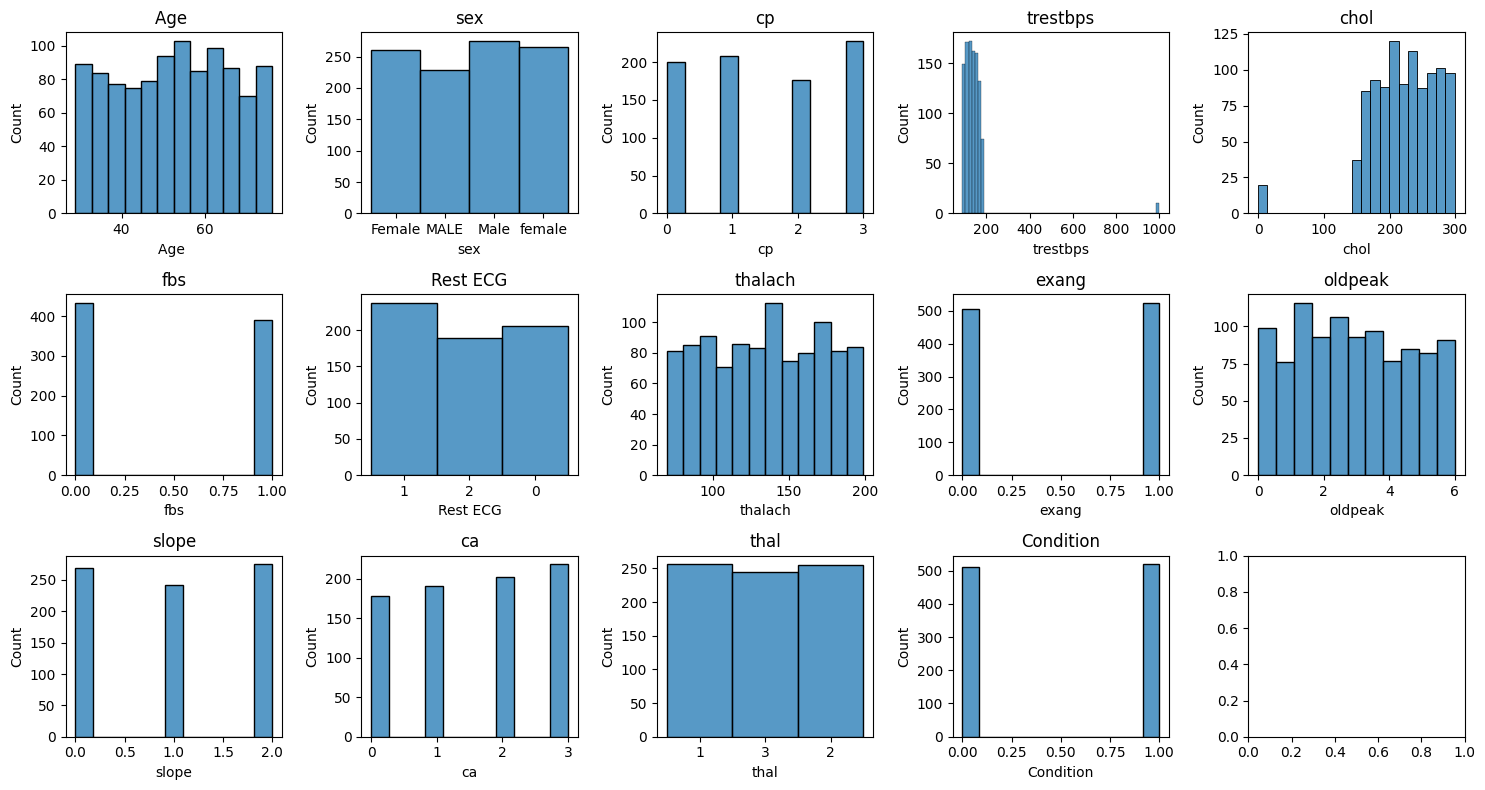

In [16]:
catco=['Age ', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'Rest ECG', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'Condition']
fig, axes = plt.subplots(3, 5, figsize=(15, 8))

for i, col in enumerate(catco):
    sns.histplot(x=col, data=df, ax=axes[i//5, i%5])
    axes[i//5, i%5].set_title(col)

plt.tight_layout()
plt.show()


In [17]:

df.drop_duplicates(inplace=True)

In [ ]:
df['sex']=df['sex'].str.lower()
df['sex']=df['sex'].replace({"male":1,"female":0})
df['chol']=df['chol'].fillna(df['chol'].median())



In [ ]:
catnan=['cp','Rest ECG','slope','ca','thal','fbs']
for co in catnan:
    df[co]=df[co].fillna(df[co].mode()[0])


In [ ]:
df['oldpeak']=df['oldpeak'].fillna(df['oldpeak'].median())
df.tail()

,Age,sex,cp,trestbps,chol,fbs,Rest ECG,thalach,exang,oldpeak,slope,ca,thal,Condition
1025,51,0,NaN,137,283,0.0,2,194,0,5.6,1.0,NaN,2,1
1026,44,0,1.0,140,245,1.0,NaN,77,1,0.1,2.0,NaN,NaN,1
1027,74,1,2.0,135,208,0.0,0,72,0,0.8,0.0,3.0,1,1
1028,59,0,2.0,97,232,0.0,NaN,171,0,1.7,NaN,1.0,1,0
1029,59,0,0.0,103,192,1.0,2,106,0,2.5,NaN,NaN,1,0


In [31]:
foatco=['cp','fbs','slope']
for co in foatco:
    df[co]=df[co].astype(int)
from sklearn.preprocessing import StandardScaler
cos=['Age ','cp','trestbps','chol','Rest ECG','thalach','oldpeak','slope','ca','thal']
scaler=StandardScaler()
df[cos]=scaler.fit_transform(df[cos])

In [32]:
df.tail()

,Age,sex,cp,trestbps,chol,fbs,Rest ECG,thalach,exang,oldpeak,slope,ca,thal,Condition
1025,-0.114472,0,0.985108,-0.064255,1.173159,0,1.631628,1.608974,0,1.562939,-0.288538,0.955543,0.333150,1
1026,-0.623238,0,-0.722185,-0.030806,0.447525,1,0.025695,-1.547199,1,-1.665668,0.903768,0.955543,-0.878304,1
1027,1.557186,1,0.131462,-0.086554,-0.259013,0,-1.580238,-1.682078,0,-1.254754,-1.480844,0.955543,-0.878304,1
1028,0.466974,0,0.131462,-0.510238,0.199282,0,0.025695,0.988529,0,-0.726437,0.903768,-0.784972,-0.878304,0
1029,0.466974,0,-1.575831,-0.443341,-0.564543,1,1.631628,-0.764900,0,-0.256821,0.903768,0.955543,-0.878304,0


In [33]:
df.shape

(1000, 14)

In [34]:
df.corr(numeric_only=True)

,Age,sex,cp,trestbps,chol,fbs,Rest ECG,thalach,exang,oldpeak,slope,ca,thal,Condition
Age,1.000000,-0.078445,-0.043831,-0.009257,0.052856,0.037659,0.063052,-0.032556,-0.027661,0.003615,-0.024624,0.000655,0.062526,0.047294
sex,-0.078445,1.000000,-0.040584,-0.010028,-0.036023,0.032553,-0.006681,-0.018330,0.026207,-0.012871,0.021963,0.006110,-0.016658,0.002040
cp,-0.043831,-0.040584,1.000000,0.055113,-0.011331,-0.046570,-0.041763,-0.037059,-0.038353,0.036869,0.013504,-0.000811,-0.079992,-0.013133
trestbps,-0.009257,-0.010028,0.055113,1.000000,-0.409010,-0.045457,-0.012011,0.021798,-0.013653,0.008699,0.032614,-0.039697,-0.011970,-0.048769
chol,0.052856,-0.036023,-0.011331,-0.409010,1.000000,0.072768,0.007422,0.012837,-0.022638,-0.073760,0.016905,0.059132,0.041388,0.036086
fbs,0.037659,0.032553,-0.046570,-0.045457,0.072768,1.000000,0.000265,0.013344,0.013188,0.057264,0.007467,0.016567,0.058653,0.000989
Rest ECG,0.063052,-0.006681,-0.041763,-0.012011,0.007422,0.000265,1.000000,0.029488,-0.005911,-0.026585,-0.004075,0.035543,-0.012451,-0.012745
thalach,-0.032556,-0.018330,-0.037059,0.021798,0.012837,0.013344,0.029488,1.000000,0.015970,0.014210,-0.052874,-0.001179,-0.020797,-0.001414
exang,-0.027661,0.026207,-0.038353,-0.013653,-0.022638,0.013188,-0.005911,0.015970,1.000000,-0.073891,-0.046318,-0.034852,0.041804,-0.004081
oldpeak,0.003615,-0.012871,0.036869,0.008699,-0.073760,0.057264,-0.026585,0.014210,-0.073891,1.000000,0.008836,-0.078276,0.010107,0.032609


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
x=df.drop('Condition',axis=1)
y=df['Condition']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
model=LogisticRegression()
model.fit(x_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [36]:
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_score(y_test,y_pred)


0.495

In [37]:
confusion_matrix(y_test,y_pred)

array([[49, 61],
       [40, 50]])

In [38]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.55      0.45      0.49       110
           1       0.45      0.56      0.50        90

    accuracy                           0.49       200
   macro avg       0.50      0.50      0.49       200
weighted avg       0.51      0.49      0.49       200

